*Data Preprosseing*

In [94]:
# Import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm # Linear regression model
import scipy.stats as stats # Statistical functions
from statsmodels.multivariate.manova import MANOVA # Multivariate Analysis of Variance (MANOVA)
from statsmodels.formula.api import ols # Ordinary Least Squares (OLS) regression

In [95]:
# Display plots inside Jupyter Notebook
%matplotlib inline

# Plot style
sns.set(style="whitegrid")


df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [96]:
# Number of unique values in each column
print(df.nunique())

# Value counts for categorical variables

for col in ["Gender","Occupation","BMI Category","Sleep Disorder"]:
    print("\n",col)
    print(df[col].value_counts())

Person ID                  374
Gender                       2
Age                         31
Occupation                  11
Sleep Duration              27
Quality of Sleep             6
Physical Activity Level     16
Stress Level                 6
BMI Category                 4
Blood Pressure              25
Heart Rate                  19
Daily Steps                 20
Sleep Disorder               2
dtype: int64

 Gender
Gender
Male      189
Female    185
Name: count, dtype: int64

 Occupation
Occupation
Nurse                   73
Doctor                  71
Engineer                63
Lawyer                  47
Teacher                 40
Accountant              37
Salesperson             32
Software Engineer        4
Scientist                4
Sales Representative     2
Manager                  1
Name: count, dtype: int64

 BMI Category
BMI Category
Normal           195
Overweight       148
Normal Weight     21
Obese             10
Name: count, dtype: int64

 Sleep Disorder
Sleep Disord

----------
----------
----------
----------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
m

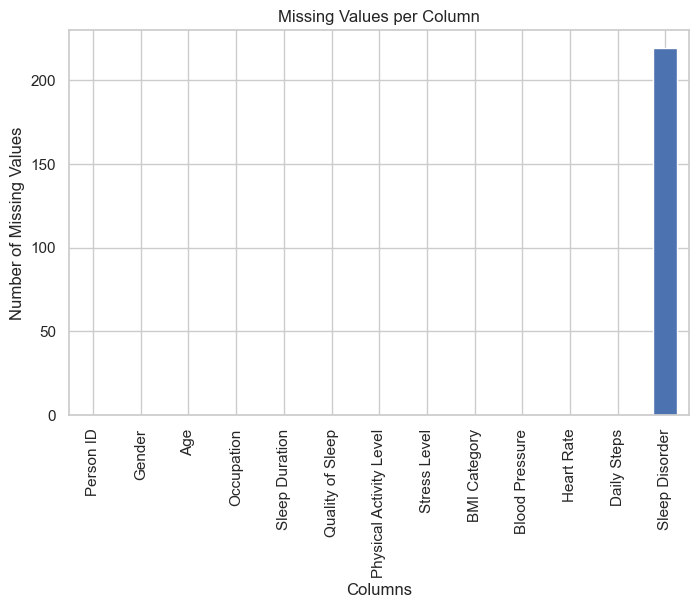

Initial Statistics of the Dataset:
         Person ID Gender         Age Occupation  Sleep Duration  \
count   374.000000    374  374.000000        374      374.000000   
unique         NaN      2         NaN         11             NaN   
top            NaN   Male         NaN      Nurse             NaN   
freq           NaN    189         NaN         73             NaN   
mean    187.500000    NaN   42.184492        NaN        7.132086   
std     108.108742    NaN    8.673133        NaN        0.795657   
min       1.000000    NaN   27.000000        NaN        5.800000   
25%      94.250000    NaN   35.250000        NaN        6.400000   
50%     187.500000    NaN   43.000000        NaN        7.200000   
75%     280.750000    NaN   50.000000        NaN        7.800000   
max     374.000000    NaN   59.000000        NaN        8.500000   

        Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
count         374.000000               374.000000    374.000000     

In [97]:
# Inspect the Data
# Display first 5 rows
df.head()
print("-"*10)
# Display last 5 rows
df.tail()
print("-"*10)
# Dataset dimensions
df.shape
print("-"*10)
# Column names
df.columns
print("-"*10)
# Data types and missing values
df.info()
print("-"*10)
# Statistical summary
df.describe()
print("-"*10)
# Check missing values
df.isnull().sum()
print("-"*10)
# Check duplicated rows
df.duplicated().sum()

missing = df.isnull().sum()

missing.plot(kind='bar', figsize=(8,5))

plt.title("Missing Values per Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")

plt.show()

# Show initial statistics of the dataset
print("Initial Statistics of the Dataset:")
print(df.describe(include='all'))

*The dataset contains no missing values in most variables. 
Missing values were only observed in the Sleep Disorder column (219 records),
representing participants without diagnosed sleep disorders. 
These missing values were replaced with "None" during data preprocessing to preserve all observations for subsequent analyses.*


Sleep Disorder
None           219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64


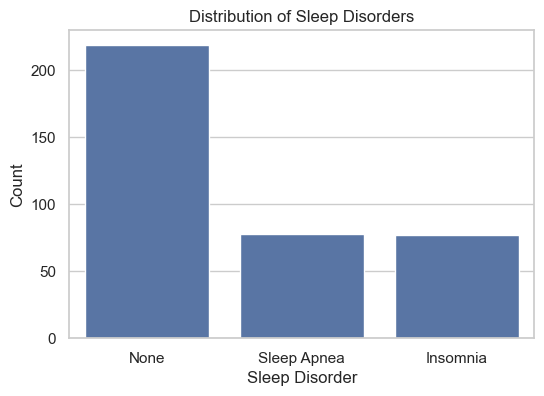

In [98]:
# Exploratory Data Analysis (EDA)

#Distribution of Sleep Disorders
import matplotlib.pyplot as plt
import seaborn as sns

# Replace missing values with "None"
df["Sleep Disorder"] = df["Sleep Disorder"].fillna("None")

# Check the distribution of sleep disorders
print(df["Sleep Disorder"].value_counts())

# Plot the distribution
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Sleep Disorder")

plt.title("Distribution of Sleep Disorders")
plt.xlabel("Sleep Disorder")
plt.ylabel("Count")

plt.show()

*Most participants (219 out of 374) did not report any sleep disorder, 
while insomnia (77 participants) and sleep apnea (78 participants) occurred in similar proportions. 
This indicates that the dataset is dominated by healthy individuals, 
with nearly balanced representation of the two major sleep disorders.*

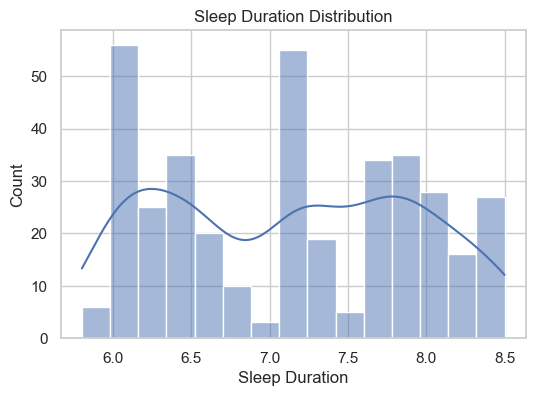

In [99]:
#Sleep Duration Distribution
plt.figure(figsize=(6,4))

sns.histplot(df["Sleep Duration"], bins=15, kde=True)

plt.title("Sleep Duration Distribution")

plt.show()

*Sleep duration among participants ranged from approximately 5.8 to 8.5 hours,
with most individuals sleeping between 6 and 8 hours. 
The distribution suggests that the majority of participants achieved sleep durations close to the recommended range for adults.*

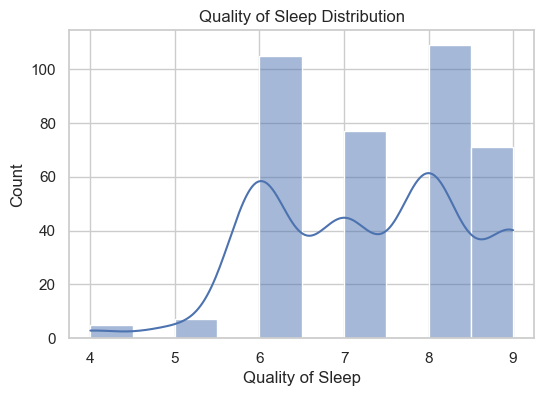

In [100]:
# Sleep Quality Distribution
plt.figure(figsize=(6,4))

sns.histplot(df["Quality of Sleep"], bins=10, kde=True)

plt.title("Quality of Sleep Distribution")

plt.show()

*Most participants reported moderate to high sleep quality, 
with ratings primarily between 6 and 9. Very low sleep quality scores were uncommon, 
indicating that the overall study population generally experienced satisfactory sleep quality.*

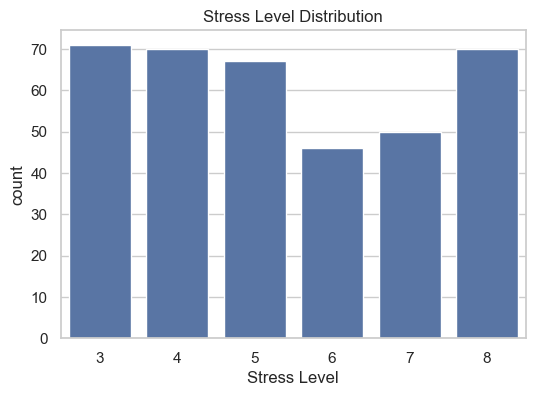

In [101]:
# Stress Level Distribution
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Stress Level")

plt.title("Stress Level Distribution")

plt.show()

*Stress levels ranged from 3 to 8, with a relatively balanced distribution across the different categories. 
Moderate stress levels were more common than extreme values, suggesting variability in perceived stress among participants.*

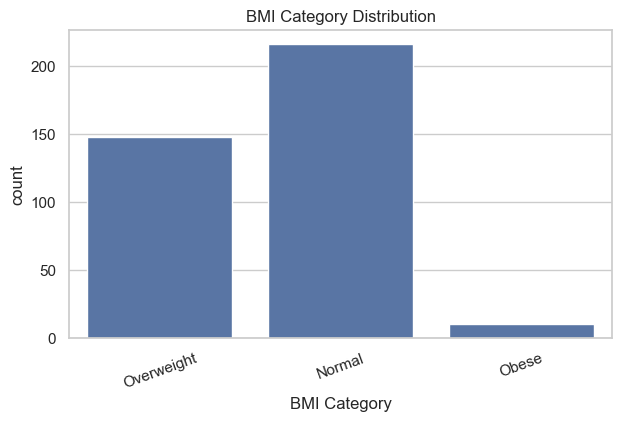

In [102]:
# BMI Categories
# Standardize BMI categories
df["BMI Category"] = df["BMI Category"].replace({
    "Normal Weight": "Normal"
})

plt.figure(figsize=(7,4))

sns.countplot(data=df, x="BMI Category")

plt.title("BMI Category Distribution")

plt.xticks(rotation=20)

plt.show()

Normal: This is the largest group in the dataset (216 individuals), meaning more than half of the population has a healthy weight.

Overweight: This is the second-largest group (148 individuals), which is a significant number for analysis.

Obese: This is the smallest group, with only 10 individuals.

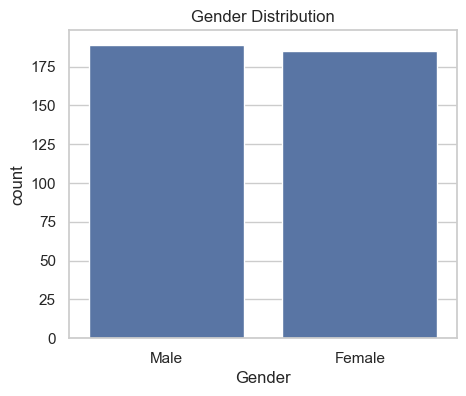

In [103]:
# Gender Distribution
plt.figure(figsize=(5,4))

sns.countplot(data=df, x="Gender")

plt.title("Gender Distribution")

plt.show()

The dataset is highly balanced between genders, with a nearly equal number of Males (189) and Females (185).

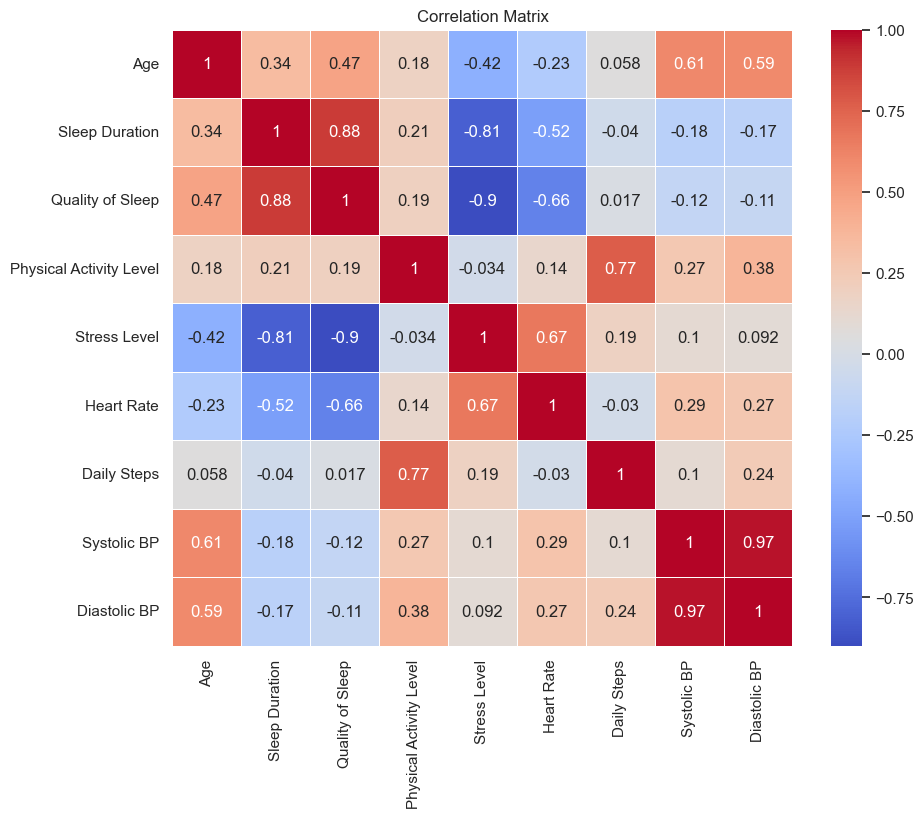

In [104]:
# Correlation Matrix
# Prepare the Data
df[["Systolic BP", "Diastolic BP"]] = df["Blood Pressure"].str.split("/", expand=True)

df["Systolic BP"] = df["Systolic BP"].astype(int)

df["Diastolic BP"] = df["Diastolic BP"].astype(int)

numeric_df = df.drop(columns=["Person ID"]).select_dtypes(include=np.number)

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix")

plt.show()

Strong Positive Relationships (Red 📈):

Sleep Duration and Quality of Sleep (0.88): Longer sleep leads to much better sleep quality.
Physical Activity Level and Daily Steps (0.77): Higher physical activity strictly means more daily steps.
Systolic BP and Diastolic BP (0.97): They move together almost perfectly; when one rises, the other does too.

Strong Negative Relationships (Blue 📉)

Stress Level and Quality of Sleep (-0.9):* Higher stress drastically reduces sleep quality.
Stress Level and Sleep Duration (-0.81): High stress strongly reduces the total hours of sleep.

No Relationship (Grey ⚪):

Daily Steps and Quality of Sleep (0.017): Walking more steps does not have a direct impact on sleep quality in this data.

In [105]:
# Outlier Detection
numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:

    Q1=df[col].quantile(0.25)

    Q3=df[col].quantile(0.75)

    IQR=Q3-Q1

    lower=Q1-1.5*IQR

    upper=Q3+1.5*IQR

    outliers=((df[col]<lower)|(df[col]>upper)).sum()

    print(col,outliers)

Person ID 0
Age 0
Sleep Duration 0
Quality of Sleep 0
Physical Activity Level 0
Stress Level 0
Heart Rate 15
Daily Steps 0
Systolic BP 0
Diastolic BP 0


In [106]:

# check new columns
df.head()
# Check Missing Values Again
df.isnull().sum()
# Remove Duplicates (if any)
df = df.drop_duplicates()
# Final Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           374 non-null    object 
 13  Systolic BP              374 non-null    int64  
 14  Diastolic BP             3

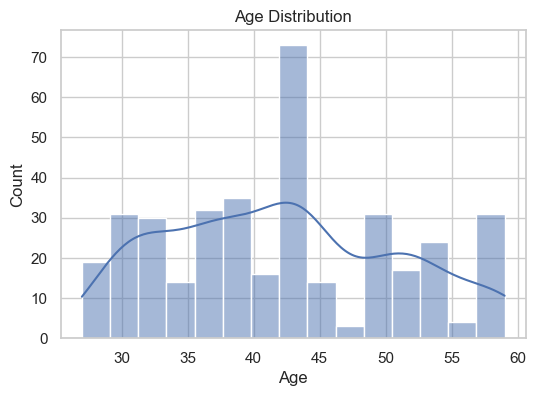

In [107]:
# Age Distribution
plt.figure(figsize=(6,4))

sns.histplot(df["Age"], bins=15, kde=True)

plt.title("Age Distribution")

plt.show()

Age Range: The dataset includes adults ranging from 27 to 59 years old.

Peak Age Group: There is a very high concentration of individuals around the age of 42-44, making it the most dominant age group in the data.

Overall Spread: Outside of that main peak, the distribution is relatively well-spread across the 30s, 40s, and 50s, giving the model a good variety of working-age adults to learn from.

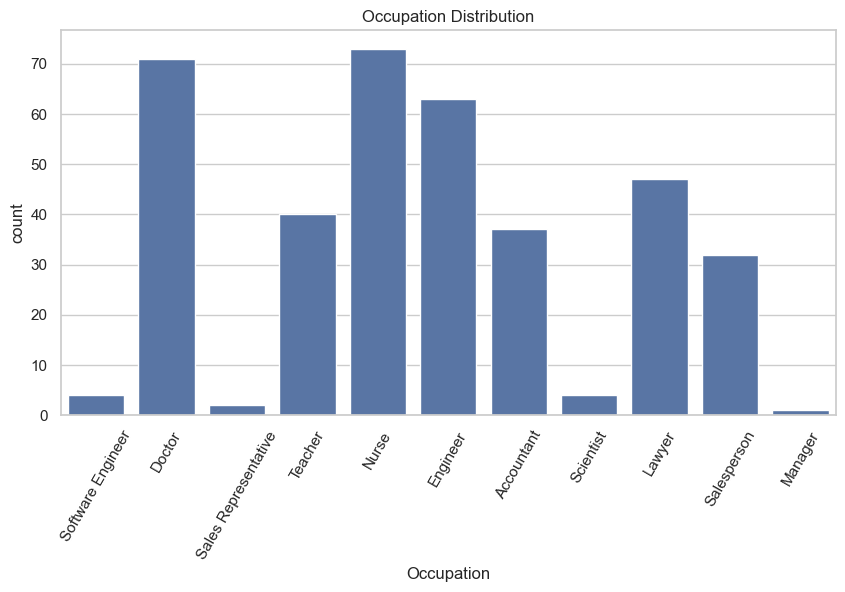

In [108]:
# Occupation Distribution
plt.figure(figsize=(10,5))

sns.countplot(data=df, x="Occupation")

plt.xticks(rotation=60)

plt.title("Occupation Distribution")

plt.show()


Top Occupations: Nurses (73) and Doctors (71) are the most common professions in the dataset, closely followed by Engineers (63).

Moderate Groups: Teachers, Accountants, Lawyers, and Salespersons form a solid, mid-sized representation.

Rare Occupations: Software Engineers, Sales Representatives, Scientists, and Managers have extremely low counts (under 5 each).

*Statistical Analysis*

In [109]:
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Systolic BP,Diastolic BP
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None,126,83
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None,125,80
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None,125,80
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90


Q1- Does achieving the optimal sleep duration and quality act as a protective factor against elevated resting heart rates, regardless of physical activity levels?

In [110]:
df.columns = df.columns.str.strip().str.replace(' ', '_')

# Specify the dependent variable (Heart Rate) and independent variables (Sleep Duration, Quality of Sleep, Physical Activity Level)
Y = df['Heart_Rate']

X = df[['Sleep_Duration', 'Quality_of_Sleep', 'Physical_Activity_Level']]

# Add a constant (intercept) to the independent variables matrix, which is a mandatory step in linear regression
X = sm.add_constant(X)

# run the regression model
model = sm.OLS(Y, X).fit()

# Print the detailed summary of the regression results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             Heart_Rate   R-squared:                       0.522
Model:                            OLS   Adj. R-squared:                  0.518
Method:                 Least Squares   F-statistic:                     134.5
Date:                Sat, 18 Jul 2026   Prob (F-statistic):           6.11e-59
Time:                        19:57:51   Log-Likelihood:                -923.20
No. Observations:                 374   AIC:                             1854.
Df Residuals:                     370   BIC:                             1870.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

Q2- Does higher stress level correlate with poorer sleep quality and shorter sleep duration? 

In [ ]:
# Write your code here

In [ ]:
# Write the code of plotting

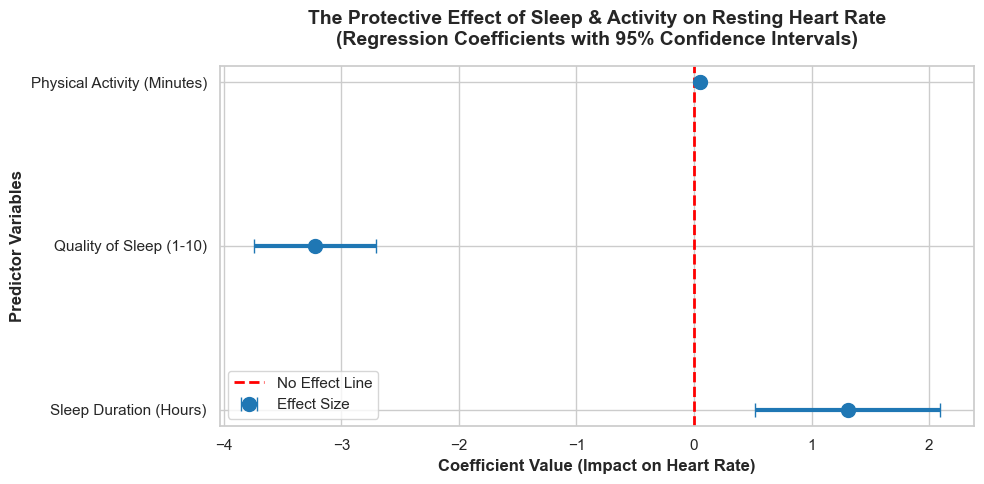

In [111]:
coef_df = pd.DataFrame({
    'Feature': model.params.index,
    'Coefficient': model.params.values,
    'Error': model.bse.values  # Standard error for each variable
})

# Filter out the constant term (intercept) to focus the plot on the main variables only
coef_df = coef_df[coef_df['Feature'] != 'const']

# Improve the names of the variables to appear aesthetically in the plot
name_mapping = {
    'Sleep_Duration': 'Sleep Duration (Hours)',
    'Quality_of_Sleep': 'Quality of Sleep (1-10)',
    'Physical_Activity_Level': 'Physical Activity (Minutes)'
}
coef_df['Feature'] = coef_df['Feature'].map(name_mapping)

# Set up the figure and style for the plot
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

# Plot the points and error bars
plt.errorbar(x=coef_df['Coefficient'], y=coef_df['Feature'], 
             xerr=coef_df['Error']*1.96, # فترات ثقة 95%
             fmt='o', color='#1f77b4', markersize=10, elinewidth=3, capsize=5, label='Effect Size')

# Add a vertical line at zero (if the variable's line crosses this zero, it means it is not statistically significant)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='No Effect Line')

# Enhance the aesthetics of the plot
plt.title('The Protective Effect of Sleep & Activity on Resting Heart Rate\n(Regression Coefficients with 95% Confidence Intervals)', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Coefficient Value (Impact on Heart Rate)', fontsize=12, fontweight='bold')
plt.ylabel('Predictor Variables', fontsize=12, fontweight='bold')
plt.legend(loc='lower left')

# Adjust the layout to prevent clipping
plt.tight_layout()
plt.show()

Q3- Which lifestyle factors are most strongly associated with sleep disorder in the dataset?

In [112]:
# Add a new binary column for Sleep Disorder: 0 means no disorder, 1 means has a disorder
df['Sleep_Disorder_Binary'] = df['Sleep_Disorder'].apply(lambda x: 0 if str(x).strip().lower() == 'none' or pd.isna(x) else 1)

# map BMI categories to numeric values for regression analysis
bmi_mapping = {'Normal': 1, 'Normal Weight': 1, 'Overweight': 2, 'Obese': 3}
df['BMI_Numeric'] = df['BMI_Category'].map(bmi_mapping)

# Identify the dependent variable (Sleep Disorder) and independent variables (Lifestyle factors we want to study)
Y_q2 = df['Sleep_Disorder_Binary']

# the independent variables (lifestyle factors we want to study)
X_q2 = df[['Stress_Level', 'BMI_Numeric', 'Daily_Steps', 'Physical_Activity_Level']]

# add the constant (intercept) which is a mandatory step in regression analysis
X_q2 = sm.add_constant(X_q2)

# step 4: build the logistic regression model and fit it
# use the Logit function to build the logistic model
logit_model = sm.Logit(Y_q2, X_q2).fit()


# step 5: print the results and calculate odds ratios
print("=== Summary Results ===")
print(logit_model.summary())

print("\n=== Odds Ratios (Odds Ratios for Easier Interpretation) ===")
    
# calculate the odds ratios by taking the exponential of the coefficients
odds_ratios = np.exp(logit_model.params)
print(odds_ratios)

Optimization terminated successfully.
         Current function value: 0.300354
         Iterations 7
=== Summary Results ===
                             Logit Regression Results                            
Dep. Variable:     Sleep_Disorder_Binary   No. Observations:                  374
Model:                             Logit   Df Residuals:                      369
Method:                              MLE   Df Model:                            4
Date:                   Sat, 18 Jul 2026   Pseudo R-squ.:                  0.5573
Time:                           19:57:51   Log-Likelihood:                -112.33
converged:                          True   LL-Null:                       -253.73
Covariance Type:               nonrobust   LLR p-value:                 5.541e-60
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -8.0568

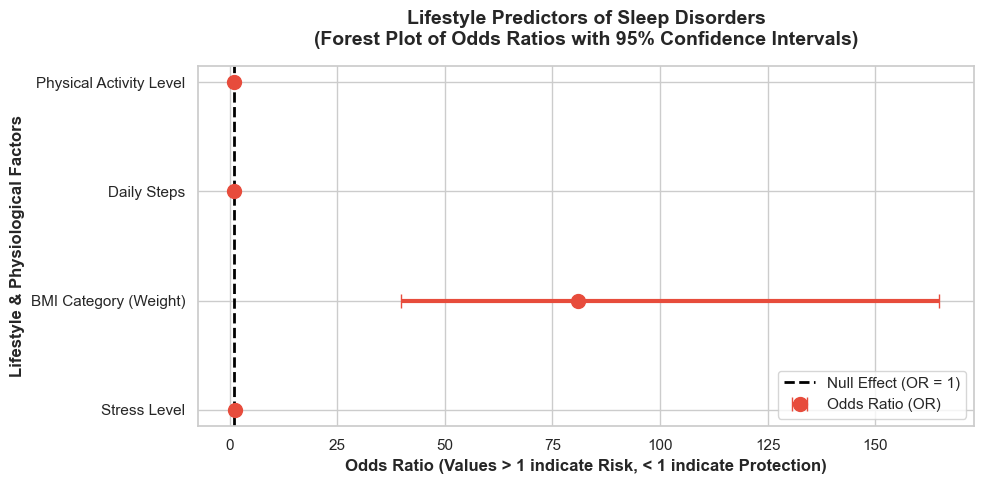

In [113]:
params = logit_model.params
conf = logit_model.conf_int()

# Create a DataFrame for plotting the odds ratios and their confidence intervals
plot_df = pd.DataFrame({
    'Feature': params.index,
    'Odds_Ratio': np.exp(params),
    'Lower_CI': np.exp(conf[0]),
    'Upper_CI': np.exp(conf[1])
})

# Exclude the constant term (const) to focus the plot on the main variables only
plot_df = plot_df[plot_df['Feature'] != 'const']

# Improve the names of the variables for a more professional appearance in the plot
name_mapping = {
    'Stress_Level': 'Stress Level',
    'BMI_Numeric': 'BMI Category (Weight)',
    'Daily_Steps': 'Daily Steps',
    'Physical_Activity_Level': 'Physical Activity Level'
}
plot_df['Feature'] = plot_df['Feature'].map(name_mapping)

# Calculate the error for each variable programmatically (to display confidence interval lines)
plot_df['Error_Lower'] = plot_df['Odds_Ratio'] - plot_df['Lower_CI']
plot_df['Error_Upper'] = plot_df['Upper_CI'] - plot_df['Odds_Ratio']

# Set up the figure and style for the plot      
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

# Plot the points and error bars for the odds ratios
plt.errorbar(x=plot_df['Odds_Ratio'], y=plot_df['Feature'], 
             xerr=[plot_df['Error_Lower'], plot_df['Error_Upper']], 
             fmt='o', color='#e74c3c', markersize=10, elinewidth=3, capsize=5, label='Odds Ratio (OR)')

# Add a vertical line at 1 (the null effect line for odds ratios)
plt.axvline(x=1, color='black', linestyle='--', linewidth=2, label='Null Effect (OR = 1)')

# Enhance the aesthetics of the plot
plt.title('Lifestyle Predictors of Sleep Disorders\n(Forest Plot of Odds Ratios with 95% Confidence Intervals)', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Odds Ratio (Values > 1 indicate Risk, < 1 indicate Protection)', fontsize=12, fontweight='bold')
plt.ylabel('Lifestyle & Physiological Factors', fontsize=12, fontweight='bold')
plt.legend(loc='lower right')

# Display the plot
plt.tight_layout()
plt.show()

Q4- Does resting heart rate differ between people with and without sleep disorders? 

In [ ]:
# Write your code here

In [ ]:
# Write the code of plotting

Q5- Are individuals with insomnia more stressed than healthy individuals? 

In [ ]:
# Write your code here

In [ ]:
# Write the code of plotting

Q6- Are there a significant difference in sleep duration and sleep quality across different BMI categories? 

Q7- Is short sleep duration associated with an increased prevalence of elevated blood pressure in the dataset?

In [114]:
df.columns = df.columns.str.strip().str.replace(' ', '_')

# Identify the dependent variable (Sleep Duration) and independent variables (Systolic and Diastolic Blood Pressure)
sleep_dur = df['Sleep_Duration']
systolic = df['Systolic_BP']
diastolic = df['Diastolic_BP']

# Perform Pearson correlation tests to assess the relationship between sleep duration and blood pressure
r_sys, p_sys = stats.pearsonr(sleep_dur, systolic)

r_dia, p_dia = stats.pearsonr(sleep_dur, diastolic)

# Print the results in a structured format
print("=== Q7: Pearson Correlation Results ===")
print(f"1. Sleep Duration vs Systolic BP:")
print(f"   - Correlation Coefficient (r): {r_sys:.4f}")
print(f"   - p-value: {p_sys:.4e}")

print(f"\n2. Sleep Duration vs Diastolic BP:")
print(f"   - Correlation Coefficient (r): {r_dia:.4f}")
print(f"   - p-value: {p_dia:.4e}")

=== Q7: Pearson Correlation Results ===
1. Sleep Duration vs Systolic BP:
   - Correlation Coefficient (r): -0.1804
   - p-value: 4.5486e-04

2. Sleep Duration vs Diastolic BP:
   - Correlation Coefficient (r): -0.1666
   - p-value: 1.2244e-03


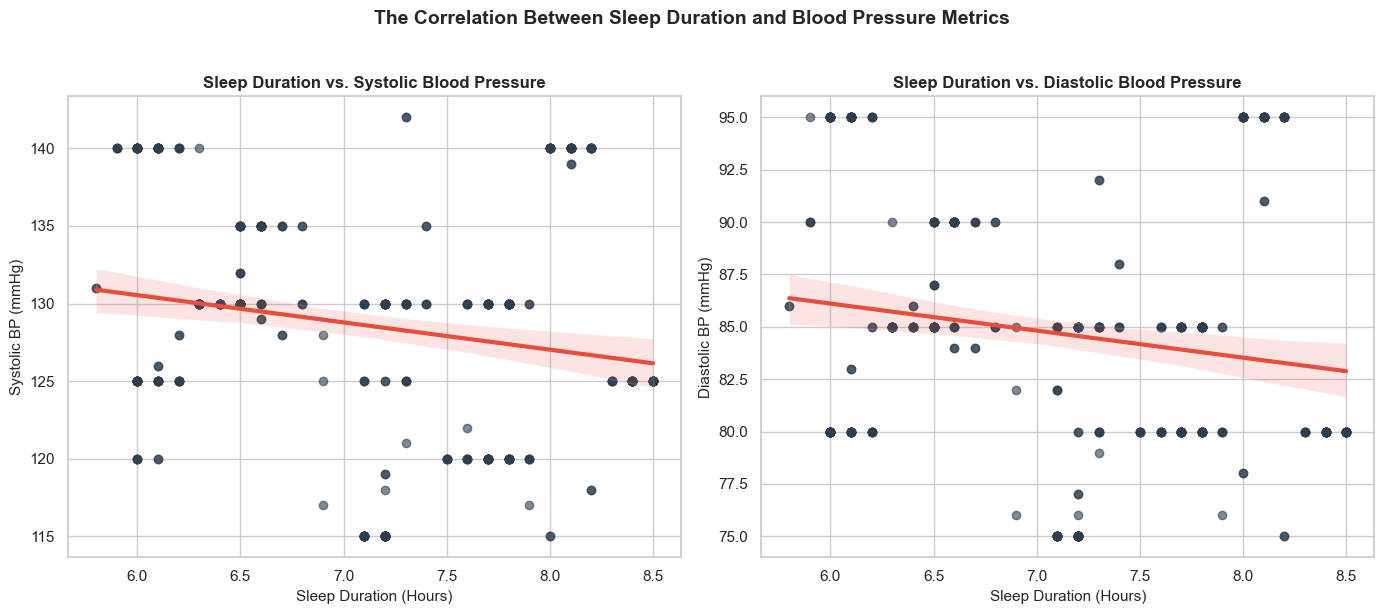

In [ ]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

# Systolic Blood Pressure vs Sleep Duration
sns.regplot(x=df['Sleep_Duration'], y=df['Systolic_BP'], ax=axes[0],
            scatter_kws={'alpha':0.6, 'color':'#2c3e50'}, 
            line_kws={'color':'#e74c3c', 'linewidth':3})
axes[0].set_title('Sleep Duration vs. Systolic Blood Pressure', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sleep Duration (Hours)', fontsize=11)
axes[0].set_ylabel('Systolic BP (mmHg)', fontsize=11)

# Diastolic Blood Pressure vs Sleep Duration
sns.regplot(x=df['Sleep_Duration'], y=df['Diastolic_BP'], ax=axes[1],
            scatter_kws={'alpha':0.6, 'color':'#2c3e50'}, 
            line_kws={'color':'#e74c3c', 'linewidth':3})
axes[1].set_title('Sleep Duration vs. Diastolic Blood Pressure', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Sleep Duration (Hours)', fontsize=11)
axes[1].set_ylabel('Diastolic BP (mmHg)', fontsize=11)

# Add a main title for the entire figure
plt.suptitle('The Correlation Between Sleep Duration and Blood Pressure Metrics', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

# Show the plots
plt.show()

Q8- What is the nature of the correlation between daily physical activity levels (measured in minutes and daily steps) and resting heart rate? 

In [ ]:
# Write your code here

In [ ]:
# Write the code of plotting

Q9- How do different occupational roles (Occupations) impact the combined metabolic and sleep profile (BMI and Sleep Duration) of individuals, and which professions are at the highest risk?

In [116]:
# Convert BMI category to numeric values
bmi_mapping = {'Normal': 1, 'Normal Weight': 1, 'Overweight': 2, 'Obese': 3}
df['BMI_Numeric'] = df['BMI_Category'].map(bmi_mapping)

# Manova Test: Assessing the effect of Occupation on Sleep Duration and BMI
maov = MANOVA.from_formula('Sleep_Duration + BMI_Numeric ~ Occupation', data=df)

print("=== 1. MANOVA Global Test Results ===")
print(maov.mv_test())

# Perform Post-Hoc Tukey Test for pairwise comparisons if MANOVA is significant
print("\n=== 2. Post-Hoc Tukey Test Results (Pairwise Comparisons) ===")

# Tukey HSD for Sleep Duration across Occupations
model_sleep = ols('Sleep_Duration ~ Occupation', data=df).fit()
anova_table_sleep = sm.stats.anova_lm(model_sleep, typ=2)
mc_sleep = sm.stats.multicomp.MultiComparison(df['Sleep_Duration'], df['Occupation'])
tukey_sleep = mc_sleep.tukeyhsd()

print("\n--- Tukey HSD for Sleep Duration across Occupations ---")
print(tukey_sleep.summary())

# Tukey HSD for BMI across Occupations
model_bmi = ols('BMI_Numeric ~ Occupation', data=df).fit()
anova_table_bmi = sm.stats.anova_lm(model_bmi, typ=2)
mc_bmi = sm.stats.multicomp.MultiComparison(df['BMI_Numeric'], df['Occupation'])
tukey_bmi = mc_bmi.tukeyhsd()

print("\n--- Tukey HSD for BMI across Occupations ---")
print(tukey_bmi.summary())

=== 1. MANOVA Global Test Results ===
                   Multivariate linear model
                                                                
----------------------------------------------------------------
       Intercept         Value  Num DF  Den DF   F Value  Pr > F
----------------------------------------------------------------
          Wilks' lambda  0.0666 2.0000 362.0000 2538.4247 0.0000
         Pillai's trace  0.9334 2.0000 362.0000 2538.4247 0.0000
 Hotelling-Lawley trace 14.0244 2.0000 362.0000 2538.4247 0.0000
    Roy's greatest root 14.0244 2.0000 362.0000 2538.4247 0.0000
----------------------------------------------------------------
                                                                
----------------------------------------------------------------
         Occupation       Value   Num DF  Den DF  F Value Pr > F
----------------------------------------------------------------
            Wilks' lambda 0.3064 20.0000 724.0000 29.2016 0.0000
       

C:\Users\althe\AppData\Local\Temp\ipykernel_1968\870289489.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sleep_Duration', y='Occupation', data=df, ax=axes[0],
C:\Users\althe\AppData\Local\Temp\ipykernel_1968\870289489.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='BMI_Numeric', y='Occupation', data=df, ax=axes[1],


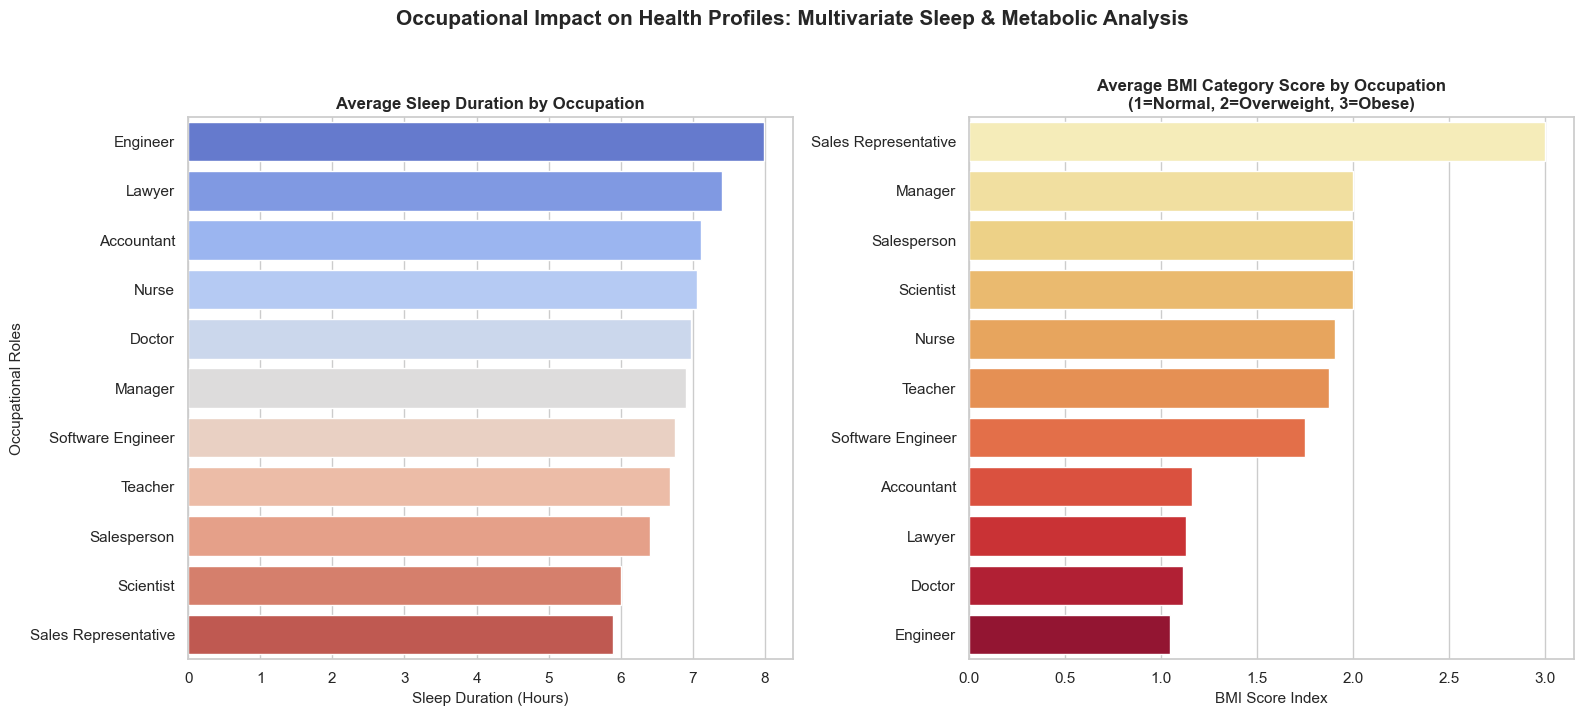

In [117]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Order occupations descendingly based on average sleep duration for a more organized and professional appearance
order_sleep = df.groupby('Occupation')['Sleep_Duration'].mean().sort_values(ascending=False).index

# First Panel: Average Sleep Duration by Occupation
sns.barplot(x='Sleep_Duration', y='Occupation', data=df, ax=axes[0], 
            order=order_sleep, palette='coolwarm', errorbar=None)
axes[0].set_title('Average Sleep Duration by Occupation', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sleep Duration (Hours)', fontsize=11)
axes[0].set_ylabel('Occupational Roles', fontsize=11)

# Order occupations descendingly based on average BMI for a more organized and professional appearance
order_bmi = df.groupby('Occupation')['BMI_Numeric'].mean().sort_values(ascending=False).index

# Second Panel: Average BMI Category Score by Occupation
sns.barplot(x='BMI_Numeric', y='Occupation', data=df, ax=axes[1], 
            order=order_bmi, palette='YlOrRd', errorbar=None)
axes[1].set_title('Average BMI Category Score by Occupation\n(1=Normal, 2=Overweight, 3=Obese)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('BMI Score Index', fontsize=11)
axes[1].set_ylabel('', fontsize=11) # Hide axis label to avoid repetition with the first plot

# 4. Improve dimensions and main title for a more professional look
plt.suptitle('Occupational Impact on Health Profiles: Multivariate Sleep & Metabolic Analysis', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()

# Display the plot
plt.show()

Q10- Are there significant differences in sleep duration, sleep quality, and stress levels between different age groups and genders?

In [118]:
df.columns = df.columns.str.strip().str.replace(' ', '_')

# Divide the Age variable into three groups: Young (<=35), Middle-Aged (36-48), and Senior (>48)
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 35, 48, 100], labels=['Young', 'Middle-Aged', 'Senior'])

print("=== Q10: Two-Way ANOVA Statistical Analysis ===\n")

# Test the impact of Age Group and Gender on Sleep and Stress Levels using Two-Way ANOVA
model_sleep = ols('Sleep_Duration ~ C(Age_Group) * C(Gender)', data=df).fit()
anova_sleep = sm.stats.anova_lm(model_sleep, typ=2)
print("1. Impact on SLEEP DURATION:")
print(anova_sleep)
print("-" * 60)

model_quality = ols('Quality_of_Sleep ~ C(Age_Group) * C(Gender)', data=df).fit()
anova_quality = sm.stats.anova_lm(model_quality, typ=2)
print("\n2. Impact on QUALITY OF SLEEP:")
print(anova_quality)
print("-" * 60)


model_stress = ols('Stress_Level ~ C(Age_Group) * C(Gender)', data=df).fit()
anova_stress = sm.stats.anova_lm(model_stress, typ=2)
print("\n3. Impact on STRESS LEVEL:")
print(anova_stress)
print("-" * 60)

=== Q10: Two-Way ANOVA Statistical Analysis ===

1. Impact on SLEEP DURATION:
                            sum_sq     df          F        PR(>F)
C(Age_Group)             23.992021    2.0  21.213104  1.908722e-09
C(Gender)                 3.360461    1.0   5.942460  1.525309e-02
C(Age_Group):C(Gender)    0.548558    2.0   0.485020  6.160777e-01
Residual                208.104002  368.0        NaN           NaN
------------------------------------------------------------

2. Impact on QUALITY OF SLEEP:
                            sum_sq     df          F        PR(>F)
C(Age_Group)             67.311569    2.0  30.375003  6.172159e-13
C(Gender)                 0.000077    1.0   0.000069  9.933576e-01
C(Age_Group):C(Gender)   13.972165    2.0   6.305076  2.030537e-03
Residual                407.747411  368.0        NaN           NaN
------------------------------------------------------------

3. Impact on STRESS LEVEL:
                            sum_sq     df          F        PR(>F)
C(A

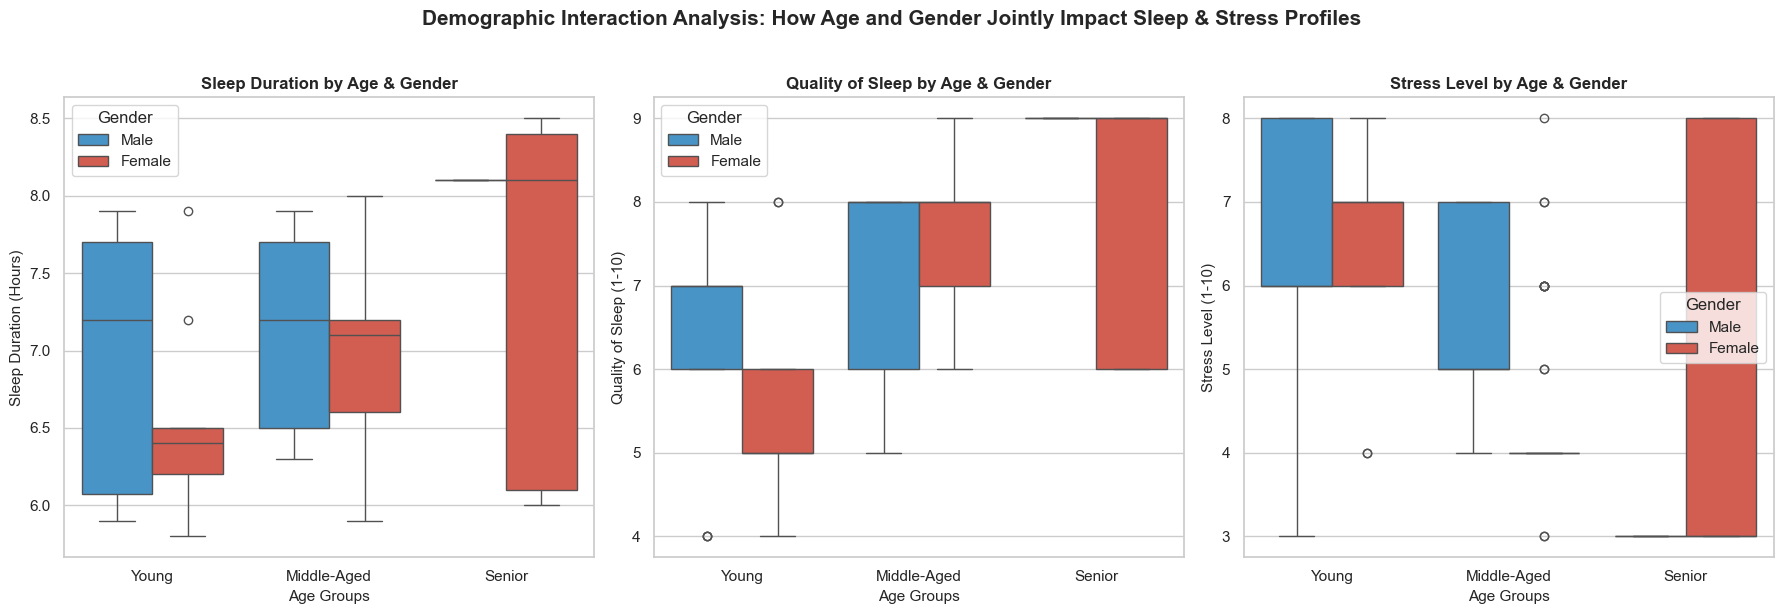

In [119]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Define the order of age groups for consistent plotting
age_order = ['Young', 'Middle-Aged', 'Senior']

# Distribution of Sleep Duration by Age Group and Gender
sns.boxplot(x='Age_Group', y='Sleep_Duration', hue='Gender', data=df, ax=axes[0],
            order=age_order, palette={'Male': '#3498db', 'Female': '#e74c3c'})
axes[0].set_title('Sleep Duration by Age & Gender', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Age Groups', fontsize=11)
axes[0].set_ylabel('Sleep Duration (Hours)', fontsize=11)

# Distribution of Quality of Sleep by Age Group and Gender
sns.boxplot(x='Age_Group', y='Quality_of_Sleep', hue='Gender', data=df, ax=axes[1],
            order=age_order, palette={'Male': '#3498db', 'Female': '#e74c3c'})
axes[1].set_title('Quality of Sleep by Age & Gender', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Age Groups', fontsize=11)
axes[1].set_ylabel('Quality of Sleep (1-10)', fontsize=11)

# Distribution of Stress Level by Age Group and Gender
sns.boxplot(x='Age_Group', y='Stress_Level', hue='Gender', data=df, ax=axes[2],
            order=age_order, palette={'Male': '#3498db', 'Female': '#e74c3c'})
axes[2].set_title('Stress Level by Age & Gender', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Age Groups', fontsize=11)
axes[2].set_ylabel('Stress Level (1-10)', fontsize=11)

# Enhance the overall appearance and layout of the figure for a more professional look
plt.suptitle('Demographic Interaction Analysis: How Age and Gender Jointly Impact Sleep & Stress Profiles', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()

# Display the plot
plt.show()